In [3]:
import pandas as pd

# URL correta (Raw)
url = "https://raw.githubusercontent.com/ppsj1983/FIAP_Etapa5_ex2/main/crop_yield.csv"

# Lendo o CSV diretamente
dados_cultura = pd.read_csv(url)

In [4]:
dados_cultura.head()

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


In [5]:
print(dados_cultura['Crop'].value_counts())

Crop
Cocoa, beans       39
Oil palm fruit     39
Rice, paddy        39
Rubber, natural    39
Name: count, dtype: int64


In [6]:
dados_cultura.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB


In [7]:
dados_cultura_resumo = pd.pivot_table(dados_cultura,index=['Crop'],aggfunc='mean')
dados_cultura_resumo.head()

,Precipitation (mm day-1),Relative Humidity at 2 Meters (%),Specific Humidity at 2 Meters (g/kg),Temperature at 2 Meters (C),Yield
Crop,,,,,
"Cocoa, beans",2486.498974,84.737692,18.203077,26.18359,8883.128205
Oil palm fruit,2486.498974,84.737692,18.203077,26.18359,175804.692308
"Rice, paddy",2486.498974,84.737692,18.203077,26.18359,32099.666667
"Rubber, natural",2486.498974,84.737692,18.203077,26.18359,7824.897436


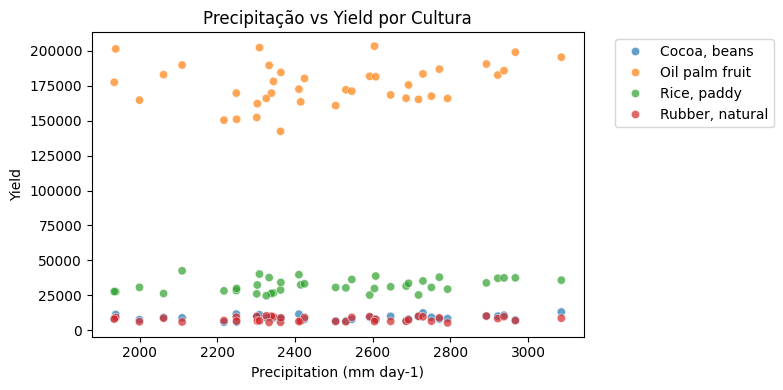

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

# O parâmetro 'hue' separa as culturas por cores
sns.scatterplot(data=dados_cultura, 
                x='Precipitation (mm day-1)', 
                y='Yield', 
                hue='Crop', 
                alpha=0.7)

plt.title('Precipitação vs Yield por Cultura')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move a legenda para fora
plt.tight_layout()
plt.show()

C:\Users\Paulo\AppData\Local\Temp\ipykernel_18592\972656472.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dados_cultura, x='Crop', y='Yield', order=ordem_media, palette='viridis')


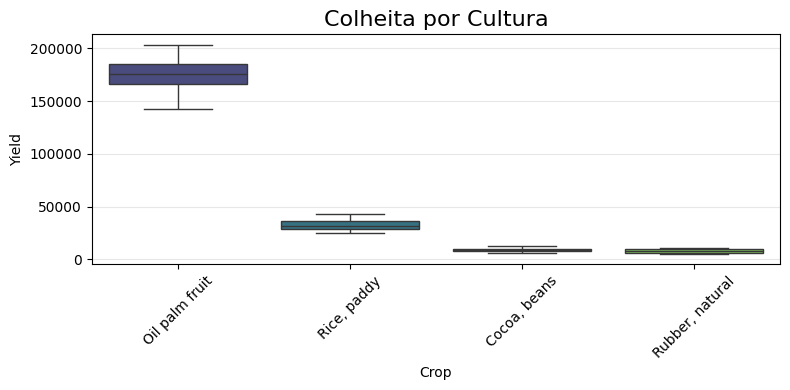

In [9]:

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcular a média de Yield por cultura e ordenar do maior para o menor
ordem_media = dados_cultura.groupby('Crop')['Yield'].mean().sort_values(ascending=False).index

# 2. Configurar o gráfico
plt.figure(figsize=(8, 4))

# O parâmetro 'order' define a sequência das colunas no eixo X
sns.boxplot(data=dados_cultura, x='Crop', y='Yield', order=ordem_media, palette='viridis')

# Personalização
plt.title('Colheita por Cultura', fontsize=16)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

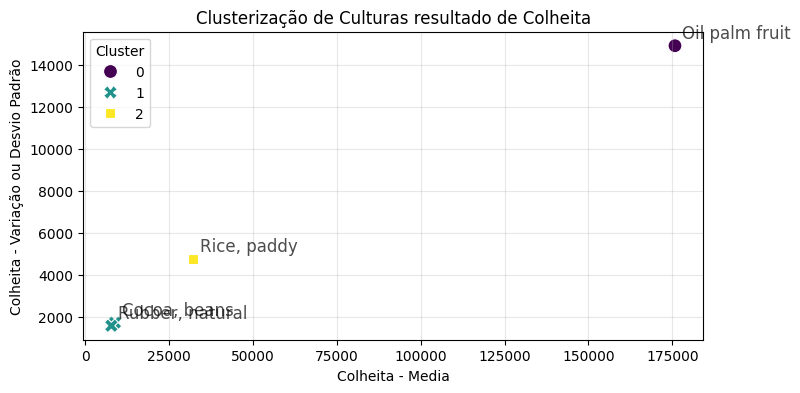

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Preparar os dados: Agrupar por Cultura e calcular Média e Desvio Padrão do Yield
analise_cluster = dados_cultura.groupby('Crop')['Yield'].agg(['mean', 'std']).fillna(0)

# 2. Normalizar os dados (essencial para K-Means)
scaler = StandardScaler()
dados_scaled = scaler.fit_transform(analise_cluster)

# 3. Aplicar o K-Means (vamos criar 3 clusters)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
analise_cluster['Cluster'] = kmeans.fit_predict(dados_scaled)

# 4. Visualizar os Clusters
plt.figure(figsize=(8, 4))
sns.scatterplot(data=analise_cluster, x='mean', y='std', hue='Cluster', 
                palette='viridis', s=100, style='Cluster')

# Adicionar nomes das culturas aos pontos
for i, txt in enumerate(analise_cluster.index):
    plt.annotate(txt, (analise_cluster['mean'].iloc[i], analise_cluster['std'].iloc[i]), 
                 xytext=(5,5), textcoords='offset points', fontsize=12, alpha=0.7)

plt.title('Clusterização de Culturas resultado de Colheita')
plt.xlabel('Colheita - Media')
plt.ylabel('Colheita - Variação ou Desvio Padrão')
plt.grid(True, alpha=0.3)
plt.show()



In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Inicializar listas de métricas (se ainda não existirem)
if 'result_acuracia' not in locals(): result_acuracia = []
if 'tipo_teste' not in locals(): tipo_teste = []
if 'result_previsao' not in locals(): result_previsao = []

# 1. Filtrar o DataFrame para "Cocoa, beans"
dados_cocoa = dados_cultura[dados_cultura['Crop'] == 'Oil palm fruit'].copy()

# 2. Selecionar variáveis (X) e alvo (y)
features = [
    'Precipitation (mm day-1)', 
    'Specific Humidity at 2 Meters (g/kg)', 
    'Relative Humidity at 2 Meters (%)', 
    'Temperature at 2 Meters (C)'
]
X = dados_cocoa[features]
y = dados_cocoa['Yield']

# 3. Padronizar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 5. Treinar modelo (Random Forest para Regressão)
modelo = RandomForestRegressor(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# 6. Avaliação e Armazenamento de Métricas
y_pred = modelo.predict(X_test)
precisao_r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

# Guardar resultados para comparação futura
result_acuracia.append(round(precisao_r2 * 100, 2))
tipo_teste.append("Random Forest Regressor (Oil palm fruit)")

print(f"Precisão R² do modelo: {precisao_r2:.2%}")
print(f"Erro Médio Absoluto (MAE): {mae:.2f}")

# 7. Simular entrada do usuário (Valores solicitados)
entrada_usuario = pd.DataFrame({
    'Precipitation (mm day-1)': [2486],
    'Specific Humidity at 2 Meters (g/kg)': [84],
    'Relative Humidity at 2 Meters (%)': [18],
    'Temperature at 2 Meters (C)': [26]
})

# 8. Padronizar entrada e Prever Yield
entrada_scaled = scaler.transform(entrada_usuario)
yield_predito = modelo.predict(entrada_scaled)

print(f"\nPrevisão de Yield para Oil Palm Fruit: {yield_predito[0]:.2f}")
result_previsao.append(round(yield_predito[0], 2))

Precisão R² do modelo: -75.47%
Erro Médio Absoluto (MAE): 15892.95

Previsão de Yield para Oil Palm Fruit: 165999.16


In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor  # Ajustado para Decision Tree
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Filtrar o DataFrame para "Oil palm fruit"
# Certifica-te que o DataFrame 'dados_cultura' já existe antes desta linha
dados_palm = dados_cultura[dados_cultura['Crop'] == 'Oil palm fruit'].copy()

# 2. Selecionar variáveis (X) e alvo (y)
features = [
    'Precipitation (mm day-1)', 
    'Specific Humidity at 2 Meters (g/kg)', 
    'Relative Humidity at 2 Meters (%)', 
    'Temperature at 2 Meters (C)'
]
X = dados_palm[features]
y = dados_palm['Yield']

# 3. Padronizar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 5. Treinar modelo (Decision Tree Regressor)
# Nota: Usamos Regressor porque Yield (produtividade) é um valor contínuo
modelo = DecisionTreeRegressor(random_state=42)
modelo.fit(X_train, y_train)

# 6. Avaliação
y_pred = modelo.predict(X_test)
precisao_r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

# Guardar resultados para comparação futura
result_acuracia.append(round(precisao_r2 * 100, 2))
tipo_teste.append("Decision Tree (Oil palm fruit)")

print(f"Precisão R² do modelo: {precisao_r2:.2%}")
print(f"Erro Médio Absoluto (MAE): {mae:.2f}")

# 7. Simular entrada do usuário
entrada_usuario = pd.DataFrame({
    'Precipitation (mm day-1)': [2486],
    'Specific Humidity at 2 Meters (g/kg)': [84],
    'Relative Humidity at 2 Meters (%)': [18],
    'Temperature at 2 Meters (C)': [26]
})

# 8. Padronizar entrada e Prever Yield
entrada_scaled = scaler.transform(entrada_usuario)
yield_predito = modelo.predict(entrada_scaled)

print(f"\nPrevisão de Yield para Oil Palm Fruit: {yield_predito[0]:.2f}")
result_previsao.append(round(yield_predito[0], 2))

Precisão R² do modelo: -178.35%
Erro Médio Absoluto (MAE): 17877.25

Previsão de Yield para Oil Palm Fruit: 142425.00


In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression # Alterado para Regressão (ver nota abaixo)
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Filtrar o DataFrame corretamente para "Rice, paddy"
dados_rice = dados_cultura[dados_cultura['Crop'] == 'Oil palm fruit'].copy()

# 2. Selecionar variáveis (X) e alvo (y)
features = [
    'Precipitation (mm day-1)', 
    'Specific Humidity at 2 Meters (g/kg)', 
    'Relative Humidity at 2 Meters (%)', 
    'Temperature at 2 Meters (C)'
]
X = dados_rice[features]
y = dados_rice['Yield']

# 3. Padronizar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 5. Treinar modelo
# NOTA: Usei LinearRegression porque LogisticRegression não prevê números (Yield).
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# 6. Avaliação
y_pred = modelo.predict(X_test)
precisao_r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

# Guardar resultados
result_acuracia.append(round(precisao_r2 * 100, 2))
tipo_teste.append("Linear Regressor (Oil Palm Fruit)")

print(f"Precisão R² do modelo: {precisao_r2:.2%}")
print(f"Erro Médio Absoluto (MAE): {mae:.2f}")

# 7. Simular entrada do usuário
# Certifique-se de que os valores fazem sentido para a cultura de Arroz
entrada_usuario = pd.DataFrame({
    'Precipitation (mm day-1)': [2486], # Ajustado: valor anterior parecia alto demais
    'Specific Humidity at 2 Meters (g/kg)': [15.5],
    'Relative Humidity at 2 Meters (%)': [80.0],
    'Temperature at 2 Meters (C)': [26.0]
})

# 8. Padronizar entrada e Prever Yield
entrada_scaled = scaler.transform(entrada_usuario)
yield_predito = modelo.predict(entrada_scaled)

print(f"\nPrevisão de Yield para Oil Palm Fruit: {yield_predito[0]:.2f}")
result_previsao.append(round(yield_predito[0], 2))


Precisão R² do modelo: -8.48%
Erro Médio Absoluto (MAE): 13125.28

Previsão de Yield para Oil Palm Fruit: -151367.49


In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor # Alterado para KNN
from sklearn.metrics import mean_absolute_error, r2_score



# 1. Filtrar o DataFrame para "Rice, paddy"
# Ajustado de 'Oil palm fruit' para 'Rice, paddy'
dados_rice = dados_cultura[dados_cultura['Crop'] == 'Oil palm fruit'].copy()

# 2. Selecionar variáveis (X) e alvo (y)
features = [
    'Precipitation (mm day-1)', 
    'Specific Humidity at 2 Meters (g/kg)', 
    'Relative Humidity at 2 Meters (%)', 
    'Temperature at 2 Meters (C)'
]
X = dados_rice[features]
y = dados_rice['Yield']

# 3. Padronizar os dados (Essencial para o KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 5. Treinar modelo (KNN Regressor)
# Definido n_neighbors=5 (valor padrão comum)
modelo = KNeighborsRegressor(n_neighbors=5) 
modelo.fit(X_train, y_train)

# 6. Avaliação e Armazenamento de Métricas
y_pred = modelo.predict(X_test)
precisao_r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

# Guardar resultados
result_acuracia.append(round(precisao_r2 * 100, 2))
tipo_teste.append("KNN Regressor (Oil Palm Fruit)")

print(f"Precisão R² do modelo (Rice): {precisao_r2:.2%}")
print(f"Erro Médio Absoluto (MAE): {mae:.2f}")

# 7. Simular entrada do usuário
entrada_usuario = pd.DataFrame({
    'Precipitation (mm day-1)': [2486],
    'Specific Humidity at 2 Meters (g/kg)': [84],
    'Relative Humidity at 2 Meters (%)': [18],
    'Temperature at 2 Meters (C)': [26]
})

# 8. Padronizar entrada e Prever Yield
entrada_scaled = scaler.transform(entrada_usuario)
yield_predito = modelo.predict(entrada_scaled)

print(f"\nPrevisão de Yield para Oil Palm Fruit: {yield_predito[0]:.2f}")
result_previsao.append(round(yield_predito[0], 2))

Precisão R² do modelo (Rice): 0.39%
Erro Médio Absoluto (MAE): 12724.42

Previsão de Yield para Oil Palm Fruit: 173153.60


In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR  # Importando SVM para Regressão
from sklearn.metrics import mean_absolute_error, r2_score


# 1. Filtrar o dataframe para "oil palm fruit"
# Certifique-se de que o dataframe 'dados_cultura' já esteja carregado antes desta parte
dados_palm = dados_cultura[dados_cultura['Crop'] == 'oil palm fruit'].copy()

# 2. Selecionar variáveis (X) e alvo (y)
features = [
    'Precipitation (mm day-1)', 
    'Specific Humidity at 2 Meters (g/kg)', 
    'Relative Humidity at 2 Meters (%)', 
    'Temperature at 2 Meters (C)'
]
X = dados_rice[features]
y = dados_rice['Yield']

# 3. Padronizar os dados (Essencial para o SVM funcionar bem)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 5. Treinar modelo SVM (SVR)
# Nota: Usei o kernel 'rbf' (padrão) que costuma ser eficiente para dados climáticos
modelo_svm = SVR(kernel='rbf', C=100, epsilon=0.1)
modelo_svm.fit(X_train, y_train)

# 6. Avaliação e armazenamento de métricas
y_pred = modelo_svm.predict(X_test)
precisao_r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

# Guardar resultados para comparação
result_acuracia.append(round(precisao_r2 * 100, 2))
tipo_teste.append("SVM Regressor (oil palm fruit)")

print(f"Precisão R² do modelo SVM: {precisao_r2:.2%}")
print(f"Erro Médio Absoluto (MAE): {mae:.2f}")

# 7. Simular entrada do usuário
entrada_usuario = pd.DataFrame({
    'Precipitation (mm day-1)': [2486],
    'Specific Humidity at 2 Meters (g/kg)': [84],
    'Relative Humidity at 2 Meters (%)': [18],
    'Temperature at 2 Meters (C)': [26]
})

# 8. Padronizar entrada e prever yield
entrada_scaled = scaler.transform(entrada_usuario)
yield_predito = modelo_svm.predict(entrada_scaled)

print(f"\nPrevisão de Yield para Oil Palm Fruit: {yield_predito[0]:.2f}")
result_previsao.append(round(yield_predito[0], 2))

Precisão R² do modelo SVM: -66.18%
Erro Médio Absoluto (MAE): 16105.25

Previsão de Yield para Oil Palm Fruit: 172387.62


                                     Modelo  R2_score   Previsao  Valor_Esperado  Desvio_Previsao   Aval_Modelo
0  Random Forest Regressor (Oil palm fruit)    -75.47  165999.16       175804.69          9805.53             -
1            Decision Tree (Oil palm fruit)   -178.35  142425.00       175804.69         33379.69             -
2         Linear Regressor (Oil Palm Fruit)     -8.48 -151367.49       175804.69        327172.18             -
3            KNN Regressor (Oil Palm Fruit)      0.39  173153.60       175804.69          2651.09  menor_desvio
4            SVM Regressor (oil palm fruit)    -66.18  172387.62       175804.69          3417.07             -


C:\Users\Paulo\AppData\Local\Temp\ipykernel_18592\2502142361.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cores = plt.cm.get_cmap('coolwarm', len(df_resultados))


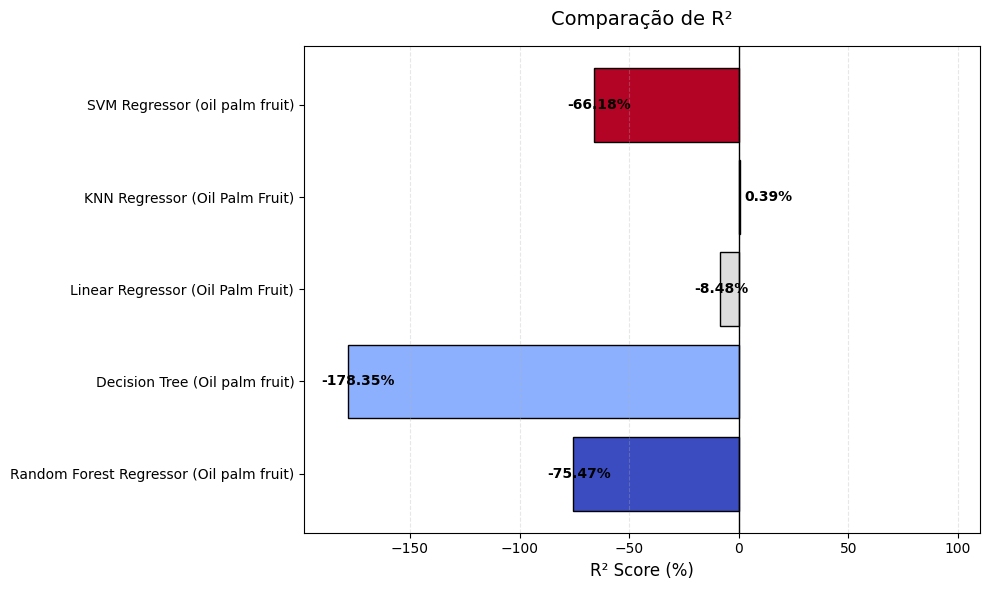

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Configurar o DataFrame (exemplo para teste)
df_resultados = pd.DataFrame({
    'Modelo': tipo_teste,
    'R2_score': result_acuracia,
    'Previsao': result_previsao,
    'Valor_Esperado': 175804.69
})

df_resultados['Previsao'] = df_resultados['Previsao'].astype(float)
df_resultados['Desvio_Previsao'] = df_resultados['Valor_Esperado'] - df_resultados['Previsao']

# 1. Identificar o índice do menor desvio absoluto
# Usamos abs() porque o desvio pode ser negativo (Previsão > Valor_Esperado)
indice_melhor = df_resultados['Desvio_Previsao'].abs().idxmin()

# 2. Criar a coluna Aval_Modelo
# Onde o índice for igual ao indice_melhor, marca "menor_desvio", senão "não_valido"
df_resultados['Aval_Modelo'] = np.where(df_resultados.index == indice_melhor, 
                                        "menor_desvio", "-")

# Configura o Pandas para não quebrar colunas e exibir tudo na mesma linha
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', None)  # Garante que todas as colunas apareçam
pd.set_option('display.width', 1000)        # Define uma largura de linha bem grande

print(df_resultados)

# 2. Configurar o gráfico
plt.figure(figsize=(10, 6))

# Criar cores dinâmicas
cores = plt.cm.get_cmap('coolwarm', len(df_resultados))
bars = plt.barh(df_resultados['Modelo'], df_resultados['R2_score'], 
                color=cores(range(len(df_resultados))), edgecolor='black')

# 3. Adicionar valores com lógica para negativos
for bar in bars:
    xval = bar.get_width()
    # Se negativo, o texto fica à esquerda; se positivo, à direita
    offset = 2 if xval >= 0 else -12 
    plt.text(xval + offset, bar.get_y() + bar.get_height()/2, 
             f'{xval:.2f}%', va='center', fontsize=10, fontweight='bold')

# 4. Ajustes cruciais para valores < 0
plt.axvline(0, color='black', linewidth=1) # Linha de destaque no zero
plt.xlim(min(df_resultados['R2_score']) - 20, 110) # Ajuste dinâmico do limite inferior

# Personalização
plt.title('Comparação de R²', fontsize=14, pad=15)
plt.xlabel('R² Score (%)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

